# FRESEAN Analysis of Alanine dipeptide (all-atom, gas phase, 300 K)

Below, we provide a simple **all-atom** FRESEAN example using `pyfresean`. The idea is to load a gas-phase trajectory, run the analysis, and plot total and per-mode vibrational densities of states (VDoS).

We provide some theortical explnataions where relevant, however, one can refer to the original [FRESEAN paper](https://pubs.acs.org/doi/10.1021/acs.jctc.2c01309) for more details.

This notebook needs to be run from the `examples/` directory with trajectory files under `input_data/MD-alanine-dipeptide-300K/`, which are automatically downloaded in the next section if they are missing.

## Setup — paths and analysis parameters

Here, we define some basic parameters for the analysis.
These parameters are passed into `FRESEAN` and `analysis.run()` used in later sections.

- **`START` / `STOP` / `STEP`** — trajectory slice (MDAnalysis-style: `START` inclusive, `STOP` exclusive). Set `STOP = None` to use all frames.
- **`N_CORR`** — number of frequency bins in the output spectrum (and maximum lag in the correlation FFT).
- **`DT`** — time between saved frames (ps); sets the frequency grid spacing together with `N_CORR`.
- **`SIGMA`** — Gaussian broadening width (cm $^{-1}$) applied in frequency space; used for smoothing the spectrum.
- **`N_CONSTRAINTS = 6`** — number of contsriants for a system. Here, for a gas-phase isolated molecule: subtract three translations and three rotations from the effective DoF (degrees of freedom) count.

In [ ]:
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import MDAnalysis as mda
import numpy as np

from pyfresean import FRESEAN, Align
from pyfresean.postprocess import low_frequency_peaks, mode_spectra, plot_spectra

INPUT_DATA = Path("input_data") / "MD-alanine-dipeptide-300K"

# trajectory window (passed to analysis.run)
START = 0        # first frame index (inclusive)
STOP = 5000      # last frame index (exclusive); None = use all frames
STEP = 1         # frame stride between analyzed frames

# FRESEAN spectral parameters
N_CORR = 500     # number of frequency bins (= max lag in the correlation FFT)
DT = 0.004       # ps between consecutive trajectory frames
SIGMA = 10.0     # cm^-1 Gaussian broadening applied in frequency space
N_CONSTRAINTS = 6  # here, for a gas phase: subtract 3 translations + 3 rotations from DoF count

# modes to inspect (1-based numbering)
MODE_NUMBERS = (1, 2)
MODE_INDICES = tuple(m - 1 for m in MODE_NUMBERS)
MAX_FREQ_PLOT = 200.0  # cm^-1, x-axis limit for VDoS plots

# helper function to download files from dropbox, if absent
def download_if_needed(path, url):
    path = Path(path)
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        print(f"Downloading {path} ...")
        urllib.request.urlretrieve(url, path)

## 1. Loading the trajectory and aligning

We read the GROMACS topology (`topol.tpr`) and trajectory (`traj.trr`), then register an **`Align`** transformation on the fly.

For each frame, `Align` finds the rotation and translation that best superimposes the current coordinates onto the harmonic minimum (`min.xyz`). That way, subsequent velocities describe **internal** motion relative to a fixed reference, not overall tumbling of the molecule in the gas phase. This is done to ensure we capture the slow collective motions of the dipeptide.

`place_com_in_box=False` — since no periodic box for this gas-phase system.

In [ ]:
# defining the source paths to the topology, trajectory, and harmonic minimum
topol = INPUT_DATA / "topol.tpr"
traj = INPUT_DATA / "traj.trr"
ref = INPUT_DATA / "min.xyz"

# downloading the files from dropbox, if absent
download_if_needed(
    topol,
    "https://www.dropbox.com/scl/fi/zux7notw4x9omhqj1rngj/topol.tpr?rlkey=svz7x62n0g4sooee10vp968zp&dl=1",
)
download_if_needed(
    traj,
    "https://www.dropbox.com/scl/fi/vhbtq7x3vqdap5t3i0vlw/traj.trr?rlkey=cffmtm0tysiy85bd3luaa46af&dl=1",
)

# loading the trajectory and selecting all atoms here for our analysis
u = mda.Universe(str(topol), str(traj))
sel = u.select_atoms("all")

# loading the harmonic minimum as a reference structure
u_ref = mda.Universe(str(ref))
ref_positions = u_ref.atoms.positions.copy()

# adding the alignment transformation to the trajectory, as described above
u.trajectory.add_transformations(
    Align(
        sel,
        reference_positions=ref_positions,
        place_com_in_box=False,  # gas phase: no periodic box wrapping
    ),
)

# number of frames to use
n_use = (len(u.trajectory) if STOP is None else STOP) - START
print(f"Atoms: {sel.n_atoms}")
print(f"Trajectory frames: {len(u.trajectory)} (using [{START}:{STOP}:{STEP}], ~{n_use // STEP} frames)")

Atoms: 22
Trajectory frames: 250001 (using [0:5000:1], ~5000 frames)


## 2. Run FRESEAN analysis

`FRESEAN` is the main class that runs the analysis. One can initialize an object of the class with the trajectory, the selection string, and the number of constraints.

Calling `FRESEAN.run()`, pyfresean loops over the frame window and, for each frame does the following:

1. Reads aligned atomic velocities $\mathbf{v}_i$.
2. Stores mass-weighted components $\tilde{\mathbf{v}}_i = \sqrt{m_i}\,\mathbf{v}_i$.
3. After reading all frames: FFTs along time $\rightarrow$ builds $\tilde{\mathbf{v}}_i \tilde{\mathbf{v}}^{\dagger}_j$ products $\rightarrow$ iFFT followed by lag windowing based on $n_{corr}$ and smoothing with $\sigma$ $\rightarrow$ a final FFT to give the **spectral correlation matrix** $\mathbf{C}(\omega)$.
4. Diagonalizes $\mathbf{C}(\omega)$ at each $\omega$ to obtain eigenvalues $\lambda_k(\omega)$ and eigenvectors $\mathbf{v}_k(\omega)$.

The total VDoS is then obtained by summing over all eigenvalues at each frequency: $g(\omega) = \sum_k \lambda_k(\omega)$, normalized with the inferred temperature and $3N - n_{\mathrm{constraints}}$ degrees of freedom.

Results land in `analysis.results`: `freqs`, `vdos_total`, `eigenvectors`, `corr_matrix`, etc.

In [3]:
analysis = FRESEAN(
    u,
    select="all",
    n_constraints=N_CONSTRAINTS,
    n_corr=N_CORR,
    dt=DT,
    sigma=SIGMA,
)
analysis.run(start=START, stop=STOP, step=STEP)

freqs = analysis.results.freqs
vdos = analysis.results.vdos_total
eigenvectors = analysis.results.eigenvectors
corr = analysis.results.corr_matrix
avg_temp = analysis.results.avg_temperature

## 3. Plot total VDoS

The total vibrational density of states, which is the sum of all eigenvalue contributions at each frequency, can be visualized (using `plot_spectra()` helper function) as follows:

$$g(\omega) = \sum_k \lambda_k(\omega)$$

Vertical lines here, mark local maxima of $g(\omega)$ below 200 cm $^{-1}$ (using `low_frequency_peaks()` helper function). Peaks in this range are the slow collective motions of the dipeptide.

Average temperature: 276.6 K
Low-frequency peaks (cm-1): [ 58.43213213 158.6015015  191.99129129]


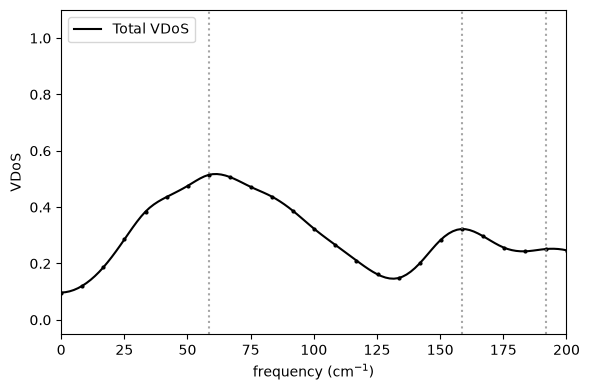

In [4]:
low_peaks = low_frequency_peaks(freqs, vdos, max_freq=MAX_FREQ_PLOT)
print(f"Average temperature: {avg_temp:.1f} K")
print(f"Low-frequency peaks (cm-1): {freqs[low_peaks]}")

fig, ax = plt.subplots(figsize=(6, 4))
plot_spectra(
    freqs,
    vdos,
    ax=ax,
    xlim=(0, MAX_FREQ_PLOT),
    labels="Total VDoS",
    vlines=freqs[low_peaks].tolist(),
)
plt.tight_layout()
plt.show()

## 4. Per-mode VDoS

Once $\mathbf{C}(\omega)$ is calculated, one can ask how a **single mode** $\mathbf{v}_k$ — taken from the eigenvector matrix at a chosen frequency $\omega_0$ — contributes across the full spectrum **without re-running FRESEAN along projected velocities**:

$$g_k(\omega) = \mathbf{v}_k^{\mathsf T}\,\mathbf{C}(\omega)\,\mathbf{v}_k$$

`mode_spectra(corr, modes)` evaluates this at all frequencies for each set of modes specified in `modes`.

Here we pick **modes 1 and 2** from the **first low-frequency peak** (`low_peaks[0]`) and overlay their $g_k(\omega)$ alongside the total $g(\omega)$.

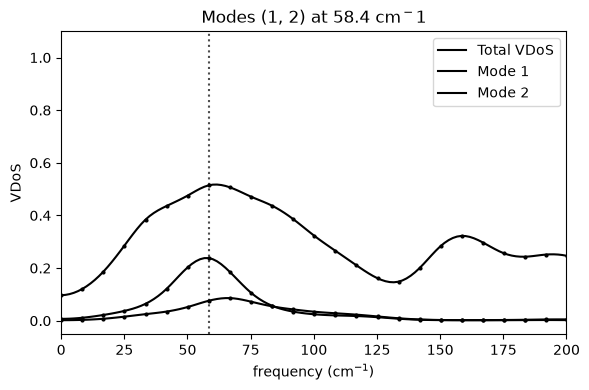

In [6]:
freq_idx = int(low_peaks[0])  # first low-frequency peak
modes = eigenvectors[freq_idx, MODE_INDICES]
mode_vdos = mode_spectra(corr, modes)

fig, ax = plt.subplots(figsize=(6, 4))
plot_spectra(freqs,vdos, ax=ax, labels="Total VDoS", colors=["black"], 
            linestyles=["-"], vlines=freqs[freq_idx], vline_colors=["black"])
for i, mode_num in enumerate(MODE_NUMBERS):
    plot_spectra(freqs, mode_vdos[i], ax=ax, labels=f"Mode {mode_num}")
ax.set_xlim(0, MAX_FREQ_PLOT)
ax.set_title(f"Modes {MODE_NUMBERS} at {freqs[freq_idx]:.1f} cm$^{-1}$")
plt.tight_layout()
plt.show()